In [14]:
import pandas as pd
import altair as alt
import seaborn as sns
import matplotlib.pyplot as plt

We will use four datasets in this project:
- Number of deaths caused by CO poisoning - Global Burden of Disease (GBD)
- Access to clean fuels and technologies for cooking (% of population)
- Temperature data by country
- 2023 Global Country Development & Prosperity Index




# Data Cleaning

In [2]:
# Read data
df_CO_death = pd.read_csv('data/IHME-GBD_2023_DATA-0d9a0352-1.csv')
df_clean_fuel = pd.read_csv('data/access-to-clean-fuels-and-technologies-for-cooking.csv')
df_development = pd.read_csv('data/country_development_2023_clean.csv')
df_temperature = pd.read_csv('data/average_temperature_1991-2020.csv')

In [3]:
df_CO_death_rate = df_CO_death[df_CO_death['metric'] == 'Rate']
df_CO_death_rate = df_CO_death_rate.drop(columns=['metric', 'upper', 'lower']).rename(columns={'val': 'death_rate_per_100k'})

In [4]:
df_clean_fuel = df_clean_fuel.rename(columns={'Entity': 'location', 'Year': 'year', 'Proportion of population with primary reliance on clean fuels and technologies for cooking (%) - Residence area type: Total': 'clean_fuel_access_pct'})

In [5]:
df_development = df_development.rename(columns={'Country': 'location'})
df_development['year'] = [2023] * len(df_development)

In [6]:
df_temperature['AvgTemp_C'] = df_temperature["AvgTemp_C"].str.split("°C").str[0].str.replace("−", "-", regex=False).astype(float)
df_temperature = df_temperature.rename(columns={'Country': 'location', 'AvgTemp_C': 'avg_temp_1991_2020'})

In [7]:
df_full = df_CO_death_rate.merge(df_clean_fuel, on=['location', 'year'], how='left')

In [8]:
df_full = df_full.merge(df_development, on=['location', 'year'], how='left')

In [9]:
df_full = df_full.merge(df_temperature, on=['location'], how='left')

In [11]:
df_full

,measure,location,sex,age,cause,year,death_rate_per_100k,Code,clean_fuel_access_pct,AveragScore,...,SocialCapital,InvestmentEnvironment,EnterpriseConditions,MarketAccessInfrastructure,EconomicQuality,LivingConditions,Health,Education,NaturalEnvironment,avg_temp_1991_2020
0,Deaths,Eswatini,Male,All ages,Poisoning by carbon monoxide,2000,0.413385,SWZ,24.9,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20.64
1,Deaths,Eswatini,Female,All ages,Poisoning by carbon monoxide,2000,0.024009,SWZ,24.9,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20.64
2,Deaths,Eswatini,Male,<1 year,Poisoning by carbon monoxide,2000,0.587965,SWZ,24.9,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20.64
3,Deaths,Eswatini,Female,<1 year,Poisoning by carbon monoxide,2000,0.355532,SWZ,24.9,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20.64
4,Deaths,Estonia,Male,All ages,Poisoning by carbon monoxide,2000,4.503623,EST,100.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.34
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19579,Deaths,Libya,Female,<1 year,Poisoning by carbon monoxide,2021,0.504484,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,22.81
19580,Deaths,United Republic of Tanzania,Male,All ages,Poisoning by carbon monoxide,2023,0.153281,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
19581,Deaths,United Republic of Tanzania,Female,All ages,Poisoning by carbon monoxide,2023,0.004071,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
19582,Deaths,United Republic of Tanzania,Male,<1 year,Poisoning by carbon monoxide,2023,0.756187,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [19]:
df_full.to_csv('data/combined_data.csv', index=False)
df_full.to_parquet('data/combined_data.parquet', index=False)

# EDA

In [17]:
df_full.columns

Index(['measure', 'location', 'sex', 'age', 'cause', 'year',
       'death_rate_per_100k', 'Code', 'clean_fuel_access_pct', 'AveragScore',
       'SafetySecurity', 'PersonelFreedom', 'Governance', 'SocialCapital',
       'InvestmentEnvironment', 'EnterpriseConditions',
       'MarketAccessInfrastructure', 'EconomicQuality', 'LivingConditions',
       'Health', 'Education', 'NaturalEnvironment', 'avg_temp_1991_2020'],
      dtype='object')

In [12]:
df_full.describe()

,year,death_rate_per_100k,clean_fuel_access_pct,AveragScore,SafetySecurity,PersonelFreedom,Governance,SocialCapital,InvestmentEnvironment,EnterpriseConditions,MarketAccessInfrastructure,EconomicQuality,LivingConditions,Health,Education,NaturalEnvironment,avg_temp_1991_2020
count,19584.000000,1.958400e+04,16512.000000,592.000000,592.000000,592.000000,592.000000,592.000000,592.000000,592.000000,592.000000,592.000000,592.000000,592.000000,592.000000,592.000000,17472.000000
mean,2011.500000,3.831822e-01,64.786010,58.117905,67.481689,57.756959,50.825608,54.700743,53.133446,55.088243,54.894527,51.370405,69.420946,68.366959,58.081351,56.297838,19.932033
std,6.922363,8.899819e-01,38.803505,13.301546,17.251861,19.531613,17.590974,10.247671,16.455893,12.227147,15.889810,13.128669,20.062577,11.317902,19.905687,9.293848,8.439077
min,2000.000000,2.612018e-09,0.000000,30.400000,16.540000,16.770000,18.200000,31.170000,22.760000,30.510000,24.230000,24.460000,19.210000,31.950000,16.780000,33.670000,-18.680000
25%,2005.750000,2.370112e-02,26.600000,47.657500,59.560000,41.097500,38.595000,48.302500,40.777500,45.840000,39.790000,41.327500,54.207500,60.387500,43.177500,50.065000,12.440000
50%,2011.500000,1.074978e-01,85.000000,57.680000,68.685000,57.560000,47.555000,54.345000,52.640000,53.875000,56.885000,50.035000,74.655000,71.465000,61.750000,55.505000,23.625000
75%,2017.250000,3.618597e-01,100.000000,66.850000,80.837500,73.240000,60.887500,60.975000,64.595000,62.842500,69.040000,62.145000,86.617500,77.370000,73.487500,62.205000,26.540000
max,2023.000000,1.466369e+01,100.000000,84.550000,96.320000,94.100000,90.410000,82.560000,84.120000,83.840000,85.750000,80.100000,95.860000,86.890000,91.440000,78.740000,30.400000


Text(0.5, 1.0, 'Distribution of CO Death Rate per 100k')

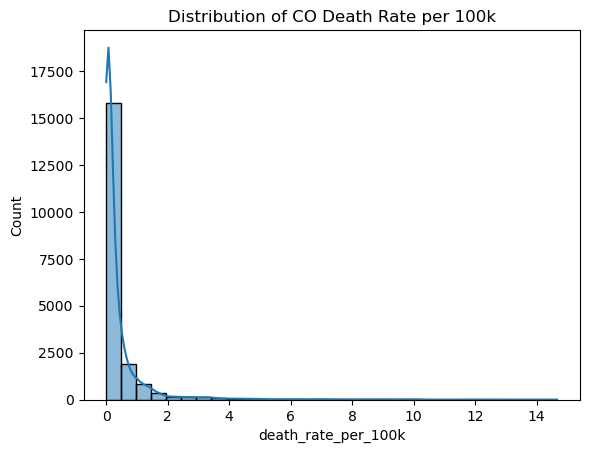

In [15]:
# Distribution of CO Death Rate
sns.histplot(df_full['death_rate_per_100k'].dropna(), bins=30, kde=True)
plt.title('Distribution of CO Death Rate per 100k')

Text(0.5, 1.0, 'Distribution of Clean Fuel Access Percentage')

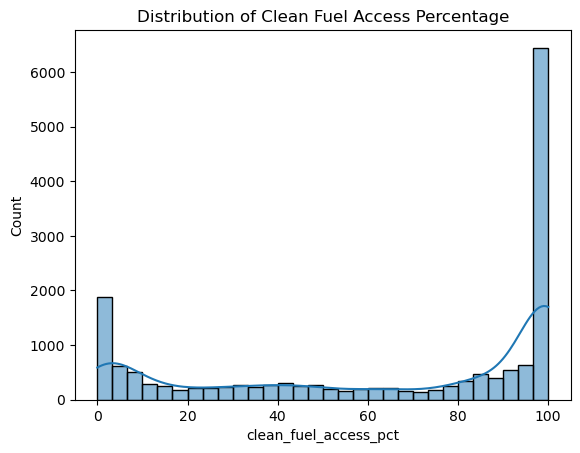

In [18]:
# Distribution of Clean Fuel Access Percentage
sns.histplot(df_full['clean_fuel_access_pct'].dropna(), bins=30, kde=True)
plt.title('Distribution of Clean Fuel Access Percentage')

Text(0.5, 1.0, 'Distribution of Average Temperature (1991-2020)')

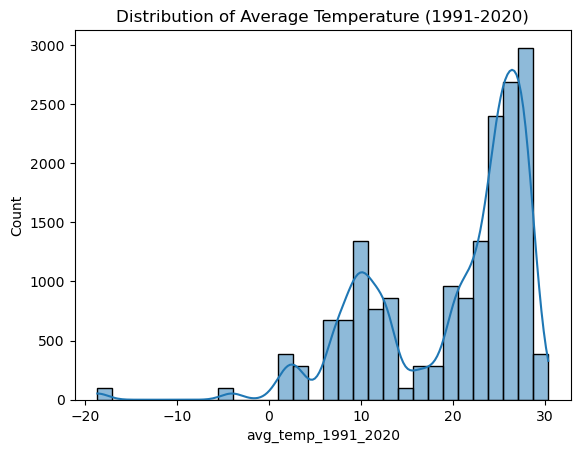

In [20]:
# Distribution of temperature
sns.histplot(df_full['avg_temp_1991_2020'].dropna(), bins=30, kde=True)
plt.title('Distribution of Average Temperature (1991-2020)')

# Research Questions

1. How are deaths evolving over time across country and region? (line chart with filter for country, heatmap of country with slider for year)
2. How is access to clean fuel related to mortality? (Scatter plot access to fuel vs co death rate - bubbe size for population, color for region, dropdown menu for country, slider for year)
<br> How has clean fuel access changed over the past 20 years globally? (Line Chart-Time Series)
<br> Which regions show the strongest improvement in clean fuel adoption? (Grouped Bar Chart)
<br> Does increased clean fuel access reduce CO-related deaths regardless of a country’s prosperity level? (Scatter Plot)
3. Is there a correlation between average temperature trends in the last few years and CO poisoning deaths? ( GBD dataset, temperature dataset, calculate the mean temperature, Bubble size: Population,  Bubble color: Clean fuel access (%), Interactive scatter plot).
4. Do more developed/prosperous countries have lower CO-related deaths? (Use GBD + Legatum Prosperity Index Grouped bar charts + Scatterplot)


